In [1]:
import sys
import os

# Get the absolute path to the parent directory (CSCI5527-FINAL)
parent_dir = os.path.abspath("..")

# Add the parent directory to the system path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
import segmentation_models_pytorch as smp
from fastai.losses import DiceLoss, CrossEntropyLossFlat

import io
import pandas as pd
from contextlib import redirect_stdout, redirect_stderr
import tqdm

from matrices import *
from preprocessing import *
from utils import *

In [3]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.backends.cudnn.is_available())
n_gpu = torch.cuda.device_count()
print(f"Total GPUs available: {n_gpu}")
for i in range(n_gpu):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print(f"Using {device} device")
generator = torch.Generator(device=device)

2.11.0+cu126
True
True
Total GPUs available: 1
Device 0: NVIDIA GeForce RTX 4070 SUPER
Using cuda:0 device


In [4]:
def baseline_model_pipeline_imagenet(base_dir, dict_files):
    # Locate project root and TACK data folders dynamically relative to the script location
    dataset_folder = os.path.join(base_dir, "TACK_Tunnel_Data")

    csv_source_dir = os.path.join(dataset_folder, "2_model_input")
    raw_mask_dir = os.path.join(dataset_folder, "3_mask")

    # Initialize pipeline pointing to the TTD dataset structure
    pipeline = TunnelDataPipeline(
        base_dir=dataset_folder,
        original_mask_dir=raw_mask_dir
    )

    # Define standard training splits for the multi-domain tunnel study
    train_files = dict_files["train_files"]
    val_files = dict_files["val_files"]
    test_files = dict_files["test_files"]

    # Step 1: Load metadata
    print("Loading CSV metadata...")
    df_train_val, df_test = pipeline.load_csv_data(
        csv_source_dir=csv_source_dir,
        train_files=train_files,
        val_files=val_files,
        test_files=test_files
    )

    # Step 2: Sanitize and separate training/validation masks
    print("Sanitizing training and validation masks...")
    df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)

    # Step 3: Sanitize test masks
    print("Sanitizing test masks...")
    df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)

    # Step 4: Compute dataset-specific normalization values
    custom_stats = None # use imagenet for baseline

    # Step 5: Finalize DataLoaders for the training loop
    print("Generating Dataloaders...")
    train_dl, val_dl, test_dl = pipeline.get_dataloaders(
        train_val_df=df_train_val_ready,
        test_df=df_test_ready,
        bs=16,
        img_size=512,
        custom_stats=custom_stats
    )

    # Final summary of training readiness
    print(f"\nPipeline Ready:")
    print(f" - Training batches: {len(train_dl)}")
    print(f" - Validation batches: {len(val_dl)}")
    print(f" - Testing batches: {len(test_dl)}")

    return train_dl, val_dl, test_dl, custom_stats

In [5]:
config = {
    "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
    "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
    "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"]
}
train_dl_imagenet, val_dl_imagenet, test_dl_imagenet, custom_stats_imagenet = baseline_model_pipeline_imagenet(parent_dir, config)

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 1360/1360 [00:00<00:00, 6384.26it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 6268.55it/s]


Generating Dataloaders...

Pipeline Ready:
 - Training batches: 66
 - Validation batches: 19
 - Testing batches: 10


In [6]:
def baseline_model_pipeline_no_weight(base_dir, dict_files):
    # Locate project root and TACK data folders dynamically relative to the script location
    dataset_folder = os.path.join(base_dir, "TACK_Tunnel_Data")

    csv_source_dir = os.path.join(dataset_folder, "2_model_input")
    raw_mask_dir = os.path.join(dataset_folder, "3_mask")

    # Initialize pipeline pointing to the TTD dataset structure
    pipeline = TunnelDataPipeline(
        base_dir=dataset_folder,
        original_mask_dir=raw_mask_dir
    )

    # Define standard training splits for the multi-domain tunnel study
    train_files = dict_files["train_files"]
    val_files = dict_files["val_files"]
    test_files = dict_files["test_files"]

    # Step 1: Load metadata
    print("Loading CSV metadata...")
    df_train_val, df_test = pipeline.load_csv_data(
        csv_source_dir=csv_source_dir,
        train_files=train_files,
        val_files=val_files,
        test_files=test_files
    )

    # Step 2: Sanitize and separate training/validation masks
    print("Sanitizing training and validation masks...")
    df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)

    # Step 3: Sanitize test masks
    print("Sanitizing test masks...")
    df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)

    # Step 4: Compute dataset-specific normalization values
    custom_stats = pipeline.calculate_training_stats(df_train_val_ready)

    # Step 5: Finalize DataLoaders for the training loop
    print("Generating Dataloaders...")
    train_dl, val_dl, test_dl = pipeline.get_dataloaders(
        train_val_df=df_train_val_ready,
        test_df=df_test_ready,
        bs=16,
        img_size=512,
        custom_stats=custom_stats
    )

    # Final summary of training readiness
    print(f"\nPipeline Ready:")
    print(f" - Training batches: {len(train_dl)}")
    print(f" - Validation batches: {len(val_dl)}")
    print(f" - Testing batches: {len(test_dl)}")

    return train_dl, val_dl, test_dl, custom_stats

In [7]:
config = {
    "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
    "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
    "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"]
}
train_dl_no_weight, val_dl_no_weight, test_dl_no_weight, custom_stats_no_weight = baseline_model_pipeline_no_weight(parent_dir, config)

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 1360/1360 [00:00<00:00, 6747.05it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 6636.49it/s]


Calculating custom dataset statistics...


Computing Stats: 100%|██████████| 1058/1058 [00:13<00:00, 78.34it/s]

Generating Dataloaders...

Pipeline Ready:
 - Training batches: 66
 - Validation batches: 19
 - Testing batches: 10


In [8]:
# because the preprocessing with the HPF is updated, so we need to re-import the functions in preprocessing_wi_filter.py
from preprocessing_wi_filter import *

In [9]:
def baseline_model_pipeline_sobelxy(base_dir, dict_files, processed_version="4_img_sobelxy"):
    # Locate project root and TACK data folders dynamically relative to the script location
    dataset_folder = os.path.join(base_dir, "TACK_Tunnel_Data")

    csv_source_dir = os.path.join(dataset_folder, "2_model_input")
    raw_mask_dir = os.path.join(dataset_folder, "3_mask")

    # Initialize pipeline pointing to the TTD dataset structure
    pipeline = TunnelDataPipeline(
        base_dir=dataset_folder,
        original_mask_dir=raw_mask_dir,
        processed_img_subdir=processed_version
    )

    # Define standard training splits for the multi-domain tunnel study
    train_files = dict_files["train_files"]
    val_files = dict_files["val_files"]
    test_files = dict_files["test_files"]

    # Step 1: Load metadata
    print("Loading CSV metadata...")
    df_train_val, df_test = pipeline.load_csv_data(
        csv_source_dir=csv_source_dir,
        train_files=train_files,
        val_files=val_files,
        test_files=test_files
    )

    # Step 2: Sanitize and separate training/validation masks
    print("Sanitizing training and validation masks...")
    df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)

    # Step 3: Sanitize test masks
    print("Sanitizing test masks...")
    df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)

    # Step 4: Compute dataset-specific normalization values
    custom_stats = pipeline.calculate_training_stats(df_train_val_ready)

    # Step 5: Finalize DataLoaders for the training loop
    print("Generating Dataloaders...")
    train_dl, val_dl, test_dl = pipeline.get_dataloaders(
        train_val_df=df_train_val_ready,
        test_df=df_test_ready,
        bs=16,
        img_size=512,
        custom_stats=custom_stats
    )

    # Final summary of training readiness
    print(f"\nPipeline Ready:")
    print(f" - Training batches: {len(train_dl)}")
    print(f" - Validation batches: {len(val_dl)}")
    print(f" - Testing batches: {len(test_dl)}")

    return train_dl, val_dl, test_dl, custom_stats

In [10]:
config = {
    "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
    "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
    "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"]
}
processed_version = "4_img_sobelxy"
train_dl_sobelxy, val_dl_sobelxy, test_dl_sobelxy, custom_stats_sobelxy = baseline_model_pipeline_sobelxy(parent_dir, config, processed_version=processed_version)

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 1360/1360 [00:00<00:00, 4517.43it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 4105.28it/s]


Calculating custom dataset statistics...


Computing Stats: 100%|██████████| 1058/1058 [00:17<00:00, 62.06it/s]

Generating Dataloaders...

Pipeline Ready:
 - Training batches: 66
 - Validation batches: 19
 - Testing batches: 10


In [11]:
def baseline_model_pipeline_sobelmaglap(base_dir, dict_files, processed_version="4_img_sobelxy"):
    # Locate project root and TACK data folders dynamically relative to the script location
    dataset_folder = os.path.join(base_dir, "TACK_Tunnel_Data")

    csv_source_dir = os.path.join(dataset_folder, "2_model_input")
    raw_mask_dir = os.path.join(dataset_folder, "3_mask")

    # Initialize pipeline pointing to the TTD dataset structure
    pipeline = TunnelDataPipeline(
        base_dir=dataset_folder,
        original_mask_dir=raw_mask_dir,
        processed_img_subdir=processed_version
    )

    # Define standard training splits for the multi-domain tunnel study
    train_files = dict_files["train_files"]
    val_files = dict_files["val_files"]
    test_files = dict_files["test_files"]

    # Step 1: Load metadata
    print("Loading CSV metadata...")
    df_train_val, df_test = pipeline.load_csv_data(
        csv_source_dir=csv_source_dir,
        train_files=train_files,
        val_files=val_files,
        test_files=test_files
    )

    # Step 2: Sanitize and separate training/validation masks
    print("Sanitizing training and validation masks...")
    df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)

    # Step 3: Sanitize test masks
    print("Sanitizing test masks...")
    df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)

    # Step 4: Compute dataset-specific normalization values
    custom_stats = pipeline.calculate_training_stats(df_train_val_ready)

    # Step 5: Finalize DataLoaders for the training loop
    print("Generating Dataloaders...")
    train_dl, val_dl, test_dl = pipeline.get_dataloaders(
        train_val_df=df_train_val_ready,
        test_df=df_test_ready,
        bs=16,
        img_size=512,
        custom_stats=custom_stats
    )

    # Final summary of training readiness
    print(f"\nPipeline Ready:")
    print(f" - Training batches: {len(train_dl)}")
    print(f" - Validation batches: {len(val_dl)}")
    print(f" - Testing batches: {len(test_dl)}")

    return train_dl, val_dl, test_dl, custom_stats

In [12]:
config = {
    "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
    "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
    "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"]
}
processed_version = "4_img_sobelmaglap"
train_dl_sobelmaglap, val_dl_sobelmaglap, test_dl_sobelmaglap, custom_stats_sobelmaglap = baseline_model_pipeline_sobelmaglap(parent_dir, config, processed_version=processed_version)

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 1360/1360 [00:00<00:00, 4372.45it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 4105.17it/s]


Calculating custom dataset statistics...


Computing Stats: 100%|██████████| 1058/1058 [00:16<00:00, 64.20it/s]

Generating Dataloaders...

Pipeline Ready:
 - Training batches: 66
 - Validation batches: 19
 - Testing batches: 10


In [13]:
def baseline_model_pipeline_sobelmag_gabor(base_dir, dict_files, processed_version="4_img_sobelxy"):
    # Locate project root and TACK data folders dynamically relative to the script location
    dataset_folder = os.path.join(base_dir, "TACK_Tunnel_Data")

    csv_source_dir = os.path.join(dataset_folder, "2_model_input")
    raw_mask_dir = os.path.join(dataset_folder, "3_mask")

    # Initialize pipeline pointing to the TTD dataset structure
    pipeline = TunnelDataPipeline(
        base_dir=dataset_folder,
        original_mask_dir=raw_mask_dir,
        processed_img_subdir=processed_version
    )

    # Define standard training splits for the multi-domain tunnel study
    train_files = dict_files["train_files"]
    val_files = dict_files["val_files"]
    test_files = dict_files["test_files"]

    # Step 1: Load metadata
    print("Loading CSV metadata...")
    df_train_val, df_test = pipeline.load_csv_data(
        csv_source_dir=csv_source_dir,
        train_files=train_files,
        val_files=val_files,
        test_files=test_files
    )

    # Step 2: Sanitize and separate training/validation masks
    print("Sanitizing training and validation masks...")
    df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)

    # Step 3: Sanitize test masks
    print("Sanitizing test masks...")
    df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)

    # Step 4: Compute dataset-specific normalization values
    custom_stats = pipeline.calculate_training_stats(df_train_val_ready)

    # Step 5: Finalize DataLoaders for the training loop
    print("Generating Dataloaders...")
    train_dl, val_dl, test_dl = pipeline.get_dataloaders(
        train_val_df=df_train_val_ready,
        test_df=df_test_ready,
        bs=16,
        img_size=512,
        custom_stats=custom_stats
    )

    # Final summary of training readiness
    print(f"\nPipeline Ready:")
    print(f" - Training batches: {len(train_dl)}")
    print(f" - Validation batches: {len(val_dl)}")
    print(f" - Testing batches: {len(test_dl)}")

    return train_dl, val_dl, test_dl, custom_stats

In [14]:
config = {
    "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
    "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
    "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"]
}
processed_version = "4_img_sobelmag_gabor"
train_dl_sobelmag_gabor, val_dl_sobelmag_gabor, test_dl_sobelmag_gabor, custom_stats_sobelmag_gabor = baseline_model_pipeline_sobelmag_gabor(parent_dir, config, processed_version=processed_version)

Loading CSV metadata...
Sanitizing training and validation masks...


Sanitizing Masks: 100%|██████████| 1360/1360 [00:00<00:00, 4111.00it/s]


Sanitizing test masks...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 4457.07it/s]


Calculating custom dataset statistics...


Computing Stats: 100%|██████████| 1058/1058 [00:16<00:00, 62.93it/s]

Generating Dataloaders...

Pipeline Ready:
 - Training batches: 66
 - Validation batches: 19
 - Testing batches: 10


In [15]:
from dff_multi_model import *

model_imagenet = smp.Unet("resnet34", encoder_weights="imagenet", classes=2)
model_name_imagenet = "Unet-resnet34-imagenet_Multi-Domain"
model_imagenet.load_state_dict(torch.load(os.path.join("models", f"{model_name_imagenet}.pth")))
model_imagenet.to(device)
model_imagenet.eval()
target_layer_imagenet = model_imagenet.encoder.layer4[-1]

model_no_weight = smp.Unet("resnet34", encoder_weights="imagenet", classes=2)
model_name_no_weight = "Unet-resnet34-no_weight_Multi-Domain"
model_no_weight.load_state_dict(torch.load(os.path.join("models", f"{model_name_no_weight}.pth")))
model_no_weight.to(device)
model_no_weight.eval()
target_layer_no_weight = model_no_weight.encoder.layer4[-1]

model_imagenet_sobelxy = smp.Unet("resnet34", encoder_weights="imagenet", classes=2)
model_name_imagenet_sobelxy = "Unet-resnet34-sobelxy_Multi-Domain"
model_imagenet_sobelxy.load_state_dict(torch.load(os.path.join("models", f"{model_name_imagenet_sobelxy}.pth")))
model_imagenet_sobelxy.to(device)
model_imagenet_sobelxy.eval()
target_layer_imagenet_sobelxy = model_imagenet_sobelxy.encoder.layer4[-1]

model_imagenet_sobelmaglap = smp.Unet("resnet34", encoder_weights="imagenet", classes=2)
model_name_imagenet_sobelmaglap = "Unet-resnet34-sobelmaglap_Multi-Domain"
model_imagenet_sobelmaglap.load_state_dict(torch.load(os.path.join("models", f"{model_name_imagenet_sobelmaglap}.pth")))
model_imagenet_sobelmaglap.to(device)
model_imagenet_sobelmaglap.eval()
target_layer_imagenet_sobelmaglap = model_imagenet_sobelmaglap.encoder.layer4[-1]

model_imagenet_sobelmag_gabor = smp.Unet("resnet34", encoder_weights="imagenet", classes=2)
model_name_imagenet_sobelmag_gabor = "Unet-resnet34-sobelmag_gabor_Multi-Domain"
model_imagenet_sobelmag_gabor.load_state_dict(torch.load(os.path.join("models", f"{model_name_imagenet_sobelmag_gabor}.pth")))
model_imagenet_sobelmag_gabor.to(device)
model_imagenet_sobelmag_gabor.eval()
target_layer_imagenet_sobelmag_gabor = model_imagenet_sobelmag_gabor.encoder.layer4[-1]


In [16]:
# models_to_compare = [model_imagenet, model_noweight]
# names_to_compare = [model_name_imagenet, model_name_no_weight]
# target_layers_to_compare = [target_layer_imagenet, target_layer_no_weight]
# dataloaders = [test_dl_imagenet, test_dl_no_weight]
# custom_stats_list = [custom_stats_imagenet, custom_stats_no_weight]

# models_to_compare = [model_imagenet, model_imagenet_sobelxy]
# names_to_compare = [model_name_imagenet, model_name_imagenet_sobelxy]
# target_layers_to_compare = [target_layer_imagenet, target_layer_imagenet_sobelxy]
# dataloaders = [test_dl_imagenet, test_dl_sobelxy]
# custom_stats_list = [custom_stats_imagenet, custom_stats_sobelxy]

models_to_compare = [model_imagenet, model_no_weight, model_imagenet_sobelxy, model_imagenet_sobelmaglap, model_imagenet_sobelmag_gabor]
names_to_compare = [model_name_imagenet, model_name_no_weight, model_name_imagenet_sobelxy, model_name_imagenet_sobelmaglap, model_name_imagenet_sobelmag_gabor]
target_layers_to_compare = [target_layer_imagenet, target_layer_no_weight, target_layer_imagenet_sobelxy, target_layer_imagenet_sobelmaglap, target_layer_imagenet_sobelmag_gabor]
fallback_dataloaders = [
    [test_dl_imagenet, val_dl_imagenet, train_dl_imagenet],
    [test_dl_no_weight, val_dl_no_weight, train_dl_no_weight],
    [test_dl_sobelxy, val_dl_sobelxy, train_dl_sobelxy],
    [test_dl_sobelmaglap, val_dl_sobelmaglap, train_dl_sobelmaglap],
    [test_dl_sobelmag_gabor, val_dl_sobelmag_gabor, train_dl_sobelmag_gabor]
]
custom_stats_list = [custom_stats_imagenet, custom_stats_no_weight, custom_stats_sobelxy, custom_stats_sobelmaglap, custom_stats_sobelmag_gabor]

Calculating NMF errors for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


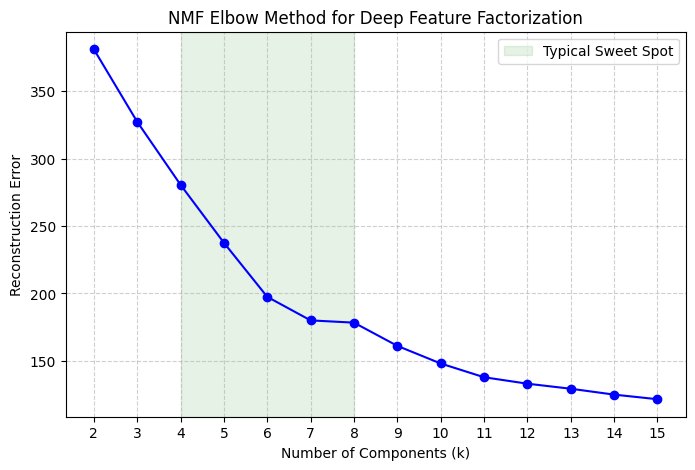

In [17]:
plot_nmf_elbow(model_imagenet, test_dl_imagenet, target_layer_imagenet, device, k_range=range(2, 16))

Calculating NMF errors for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


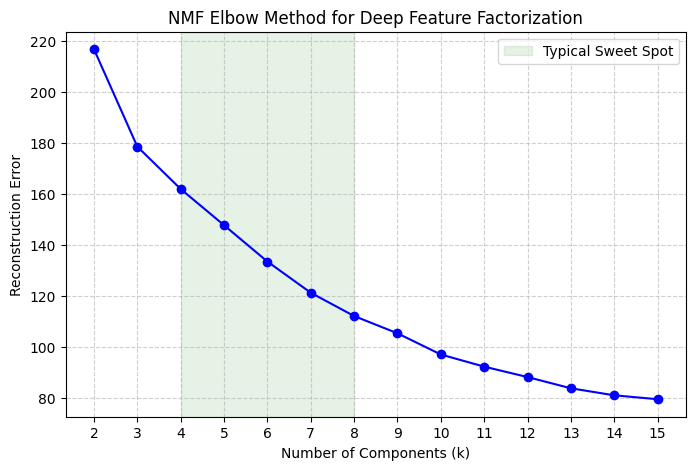

In [18]:
plot_nmf_elbow(model_no_weight, test_dl_no_weight, target_layer_no_weight, device, k_range=range(2, 16))

Calculating NMF errors for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


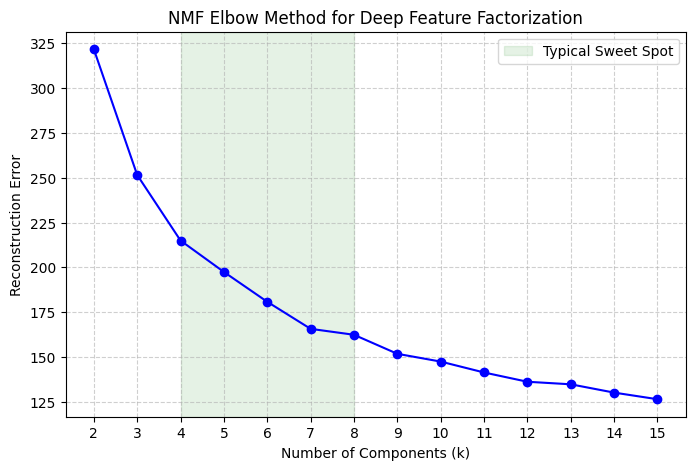

In [19]:
plot_nmf_elbow(model_imagenet_sobelxy, test_dl_sobelxy, target_layer_imagenet_sobelxy, device, k_range=range(2, 16))

Calculating NMF errors for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


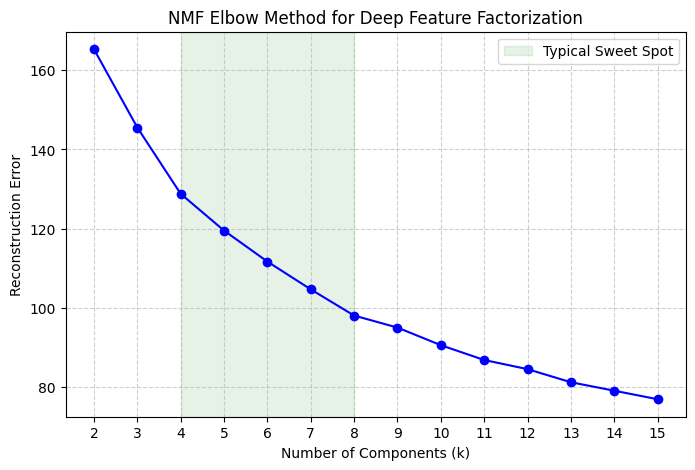

In [20]:
plot_nmf_elbow(model_imagenet_sobelmaglap, test_dl_sobelmaglap, target_layer_imagenet_sobelmaglap, device, k_range=range(2, 16))

Calculating NMF errors for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


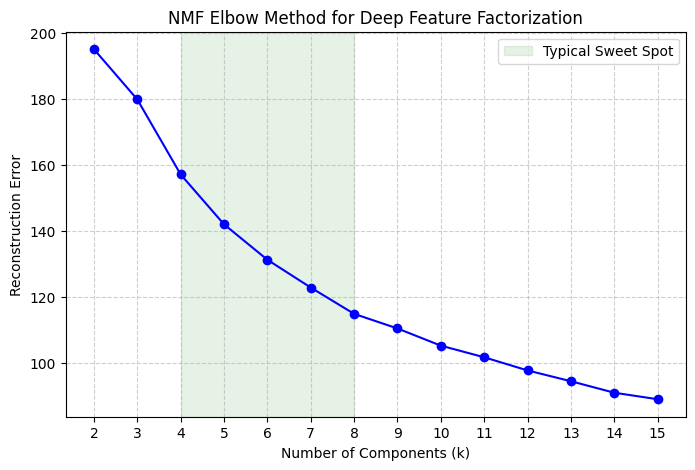

In [21]:
plot_nmf_elbow(model_imagenet_sobelmag_gabor, test_dl_sobelmag_gabor, target_layer_imagenet_sobelmag_gabor, device, k_range=range(2, 16))

In [22]:
run_dff_for_multiple_models(
    models=models_to_compare, 
    model_names=names_to_compare, 
    dataloaders_list_per_model=fallback_dataloaders, 
    target_layers=target_layers_to_compare, 
    device=device, 
    save_dir="figures/dff_analysis/k6",
    custom_stats_list=custom_stats_list, 
    n_components=6
)


--- Processing Unet-resnet34-imagenet_Multi-Domain (k=6) ---
Scanning dataloader 1/3...
Generating DFF plots for Unet-resnet34-imagenet_Multi-Domain...

--- Processing Unet-resnet34-no_weight_Multi-Domain (k=6) ---
Scanning dataloader 1/3...
Generating DFF plots for Unet-resnet34-no_weight_Multi-Domain...

--- Processing Unet-resnet34-sobelxy_Multi-Domain (k=6) ---
Scanning dataloader 1/3...
Scanning dataloader 2/3...
Generating DFF plots for Unet-resnet34-sobelxy_Multi-Domain...

--- Processing Unet-resnet34-sobelmaglap_Multi-Domain (k=6) ---
Scanning dataloader 1/3...
Scanning dataloader 2/3...
Generating DFF plots for Unet-resnet34-sobelmaglap_Multi-Domain...

--- Processing Unet-resnet34-sobelmag_gabor_Multi-Domain (k=6) ---
Scanning dataloader 1/3...
Generating DFF plots for Unet-resnet34-sobelmag_gabor_Multi-Domain...


In [23]:
run_dff_for_multiple_models(
    models=models_to_compare, 
    model_names=names_to_compare, 
    dataloaders_list_per_model=fallback_dataloaders, 
    target_layers=target_layers_to_compare, 
    device=device, 
    save_dir="figures/dff_analysis/k8",
    custom_stats_list=custom_stats_list, 
    n_components=8
)


--- Processing Unet-resnet34-imagenet_Multi-Domain (k=8) ---
Scanning dataloader 1/3...
Generating DFF plots for Unet-resnet34-imagenet_Multi-Domain...

--- Processing Unet-resnet34-no_weight_Multi-Domain (k=8) ---
Scanning dataloader 1/3...
Generating DFF plots for Unet-resnet34-no_weight_Multi-Domain...

--- Processing Unet-resnet34-sobelxy_Multi-Domain (k=8) ---
Scanning dataloader 1/3...
Scanning dataloader 2/3...
Generating DFF plots for Unet-resnet34-sobelxy_Multi-Domain...

--- Processing Unet-resnet34-sobelmaglap_Multi-Domain (k=8) ---
Scanning dataloader 1/3...
Scanning dataloader 2/3...
Generating DFF plots for Unet-resnet34-sobelmaglap_Multi-Domain...

--- Processing Unet-resnet34-sobelmag_gabor_Multi-Domain (k=8) ---
Scanning dataloader 1/3...
Generating DFF plots for Unet-resnet34-sobelmag_gabor_Multi-Domain...
